# Preprocesamiento

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import datetime
from datetime import date
from scipy import ndimage
import openeo

In [2]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Coordenadas y fechas de los lagos

In [5]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

lagos = {
    "atitlan": {"bbox": lago_atitlan, "fechas": fechas_atitlan},
    "amatitlan": {"bbox": lago_amatitlan, "fechas": fechas_amatitlan},
}

## Función para quitar máscara de agua

Esta función quita el ruido de los grupos de pixeles de agua aislados de los lagos principales

In [6]:
from scipy import ndimage

def limpiar_mascara(mascara_agua, min_pixeles=30):
    """Quita grupos de pixeles 'agua' aislados (ruido) y deja solo el cuerpo de agua principal."""
    etiquetas, n = ndimage.label(mascara_agua)
    if n == 0:
        return mascara_agua
    tamanos = ndimage.sum(mascara_agua, etiquetas, range(1, n + 1))
    componente_mas_grande = np.argmax(tamanos) + 1
    return etiquetas == componente_mas_grande

## Descarga de las bandas

In [15]:
import time

bandas_tabular = ["B02", "B03", "B04", "B08"]
os.makedirs("data_tabular", exist_ok=True)

def descargar_bandas_tabular(lago, bbox, fecha, bandas, max_intentos=4):
    out_path = f"data_tabular/{lago}_{fecha}.tif"
    if os.path.exists(out_path):
        # Validar que el archivo existente no esté corrupto (descarga cortada a medias)
        try:
            with rasterio.open(out_path) as src:
                src.read()
            return out_path
        except Exception:
            print(f"  {out_path} existe pero está corrupto (descarga incompleta). Borrando y re-descargando...")
            os.remove(out_path)

    d0 = date.fromisoformat(fecha)
    d1 = d0 + datetime.timedelta(days=1)

    for intento in range(1, max_intentos + 1):
        try:
            cube = connection.load_collection(
                "SENTINEL2_L2A",
                spatial_extent=bbox,
                temporal_extent=[str(d0), str(d1)],
                bands=bandas,
            )
            cube = cube.reduce_dimension(dimension="t", reducer="mean")
            cube.download(out_path)

            # Validar la descarga recién hecha antes de darla por buena
            with rasterio.open(out_path) as src:
                src.read()
            return out_path
        except Exception as e:
            espera = 10 * intento  # espera progresiva: 10s, 20s, 30s, 40s
            print(f"  Intento {intento}/{max_intentos} falló para {lago} {fecha} ({type(e).__name__}). "
                  f"Reintentando en {espera}s...")
            if intento == max_intentos:
                print(f"  Se agotaron los intentos para {lago} {fecha}. Sáltala y corre la celda de nuevo después.")
                raise
            time.sleep(espera)

rutas_atitlan_tab = [descargar_bandas_tabular("atitlan", lago_atitlan, f, bandas_tabular) for f in fechas_atitlan]
rutas_amatitlan_tab = [descargar_bandas_tabular("amatitlan", lago_amatitlan, f, bandas_tabular) for f in fechas_amatitlan]

## Función Raster

Por cada pixel válido guardamos su ubicación (x, y en las coordenadas del raster) y los valores de las 4 bandas. La limpieza pasa por 3 filtros antes de armar la tabla:

1. Nodata/inválidos: NaN o reflectancias negativas.
2. Fuera del lago: usamos NDWI = (B03-B08)/(B03+B08) > 0 como máscara de agua, y limpiar_mascara() para quedarnos solo con el cuerpo de agua principal.
3. Nubes/saturación: usamos una heurística, el brillo promedio de las 4 bandas por pixel. Descartamos el 0.5% de píxeles más brillantes dentro del agua, ya que un brillo anormalmente alto en agua típicamente indica nube, neblina o reflejo especular, no agua limpia.

In [16]:
def raster_a_dataframe(tif_path, lago, fecha, n_muestras=None, semilla=42, verbose=True):
    with rasterio.open(tif_path) as src:
        b02, b03, b04, b08 = src.read().astype(float)
        nodata = src.nodata
        transform = src.transform

    n_total = b02.size

    # 1. nodata / valores inválidos
    valido = np.ones(b02.shape, dtype=bool)
    for banda in (b02, b03, b04, b08):
        valido &= ~np.isnan(banda)
        if nodata is not None:
            valido &= (banda != nodata)
        valido &= (banda >= 0)

    # 2. fuera del lago
    epsilon = 1e-6
    ndwi = (b03 - b08) / (b03 + b08 + epsilon)
    mascara_agua_bruta = (ndwi > 0) & valido
    mascara_agua = limpiar_mascara(mascara_agua_bruta)

    # 3. nubes / saturación
    brillo = (b02 + b03 + b04 + b08) / 4
    if mascara_agua.any():
        umbral_brillo = np.nanpercentile(brillo[mascara_agua], 99.5)
    else:
        umbral_brillo = np.inf
    no_saturado = brillo < umbral_brillo

    mascara_final = mascara_agua & no_saturado
    n_final = mascara_final.sum()

    if verbose:
        print(f"{lago} {fecha}: {n_total:>8,} pixeles totales -> "
              f"{mascara_agua_bruta.sum():>7,} en agua (bruto) -> "
              f"{mascara_agua.sum():>7,} tras limpiar ruido -> "
              f"{n_final:>7,} tras filtrar brillo/nubes")

    filas, cols = np.where(mascara_final)
    xs, ys = rasterio.transform.xy(transform, filas, cols)

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "x": xs,
        "y": ys,
        "b02": b02[filas, cols],
        "b03": b03[filas, cols],
        "b04": b04[filas, cols],
        "b08": b08[filas, cols],
    })

    if n_muestras is not None and len(df) > 0:
        n = min(n_muestras, len(df))  # por si la fecha tiene menos pixeles validos que lo pedido
        df = df.sample(n=n, random_state=semilla).reset_index(drop=True)

    return df

## Aplicar a todos los lagos y fechas con sampling balanceado

Con 11 fechas por cada lago, cada raster tiene cientos de miles de píxeles. En vez de muestrear por porcentaje, usamos un número fijo de píxeles por fecha para que Atitlán y Amatitlán aporten cantidades comparables al dataset final (si usáramos el mismo porcentaje para ambos, Atitlán dominaría el dataset casi 17 a 1 sobre Amatitlán).

In [17]:
frames = []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data_tabular/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        df_fecha = raster_a_dataframe(tif_path, lago, fecha, n_muestras=20000)  
        frames.append(df_fecha)

df_pixeles = pd.concat(frames, ignore_index=True)
print(f"\nTotal filas en el dataset tabular final: {len(df_pixeles):,}")
print(df_pixeles["lago"].value_counts())  
df_pixeles.head()

atitlan 2025-01-18: 4,831,009 pixeles totales -> 583,930 en agua (bruto) -> 466,178 tras limpiar ruido -> 463,775 tras filtrar brillo/nubes
atitlan 2025-04-13: 4,831,009 pixeles totales -> 1,227,197 en agua (bruto) -> 1,226,318 tras limpiar ruido -> 1,220,146 tras filtrar brillo/nubes
atitlan 2025-05-13: 4,831,009 pixeles totales -> 1,397,658 en agua (bruto) -> 1,226,104 tras limpiar ruido -> 1,219,951 tras filtrar brillo/nubes
atitlan 2025-07-17: 4,831,009 pixeles totales -> 1,202,663 en agua (bruto) -> 1,199,256 tras limpiar ruido -> 1,193,251 tras filtrar brillo/nubes
atitlan 2025-11-21: 4,831,009 pixeles totales -> 1,063,387 en agua (bruto) -> 1,005,468 tras limpiar ruido -> 1,000,433 tras filtrar brillo/nubes
atitlan 2025-12-29: 4,831,009 pixeles totales -> 1,316,305 en agua (bruto) -> 1,135,134 tras limpiar ruido -> 1,129,451 tras filtrar brillo/nubes
atitlan 2026-02-12: 4,831,009 pixeles totales -> 972,593 en agua (bruto) -> 948,011 tras limpiar ruido -> 943,253 tras filtrar bri

,lago,fecha,x,y,b02,b03,b04,b08
0,atitlan,2025-01-18,694085.0,1623845.0,141.0,91.0,5.0,9.0
1,atitlan,2025-01-18,698175.0,1628185.0,112.0,97.0,12.0,6.0
2,atitlan,2025-01-18,694665.0,1628565.0,156.0,86.0,2.0,14.0
3,atitlan,2025-01-18,693555.0,1629255.0,142.0,82.0,10.0,12.0
4,atitlan,2025-01-18,694375.0,1628805.0,136.0,86.0,7.0,13.0


2025-01-18, Atitlán: esta fecha mostró un conteo de píxeles de agua notablemente menor al resto. Se inspeccionaron visualmente las 4 bandas para descartar corrupción de datos; con la escala de color ajustada a percentiles 2-98, el lago se ve completo y normal en las 4 bandas, el conteo menor se debe a variación del umbral NDWI, no a un problema del archivo.

In [20]:
for banda, nombre in zip([b02, b03, b04, b08], ["B02", "B03", "B04", "B08"]):
    print(f"{nombre}: min={np.nanmin(banda):.1f}  p2={np.nanpercentile(banda,2):.1f}  "
          f"mediana={np.nanmedian(banda):.1f}  p98={np.nanpercentile(banda,98):.1f}  max={np.nanmax(banda):.1f}")

B02: min=-999.0  p2=89.0  mediana=190.0  p98=821.0  max=18040.0
B03: min=-614.0  p2=63.0  mediana=356.0  p98=1054.0  max=17112.0
B04: min=-325.0  p2=-12.0  mediana=229.0  p98=1242.0  max=16520.0
B08: min=-108.0  p2=-29.0  mediana=2424.0  p98=4544.0  max=15784.0


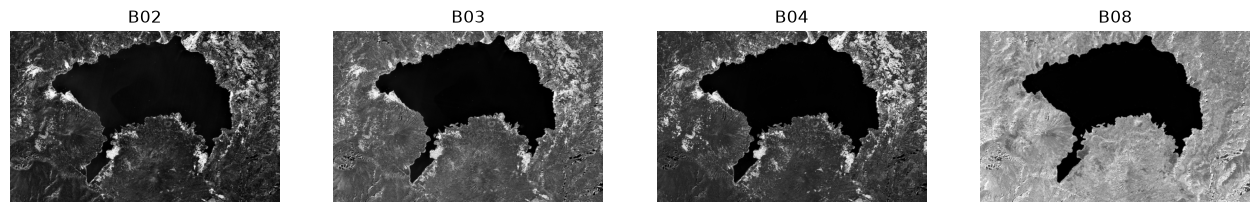

In [21]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, banda, nombre in zip(axs, [b02, b03, b04, b08], ["B02", "B03", "B04", "B08"]):
    vmin, vmax = np.nanpercentile(banda, [2, 98])
    ax.imshow(banda, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(nombre)
    ax.axis("off")
plt.show()